In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
# conda install numpy=1.26.4 pandas scipy matplotlib seaborn scikit-learn mlxtend pyarrow -c conda-forge -y
# this version is need 1.26.4

In [4]:
# conda install openpyxl -y
df = pd.read_excel(r'online_retail_II.xlsx', sheet_name='Year 2010-2011') # your directory

print(f"Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Dataset loaded: 541,910 rows and 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("=== Column types ===")
print(df.dtypes)

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Basic statistics ===")
df.describe()

=== Column types ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

=== Missing values ===
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

=== Basic statistics ===


,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [6]:
print(f"Rows before cleaning: {len(df):,}")

df = df.dropna(subset=['Customer ID'])

df = df[~df['Invoice'].astype(str).str.startswith('C')]

df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print(f"Rows after cleaning:  {len(df):,}")
print(f"Rows removed: {541909 - len(df):,}")

Rows before cleaning: 541,910
Rows after cleaning:  397,885
Rows removed: 144,024


C:\Users\aggel\AppData\Local\Temp\ipykernel_19672\1028694932.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_d')


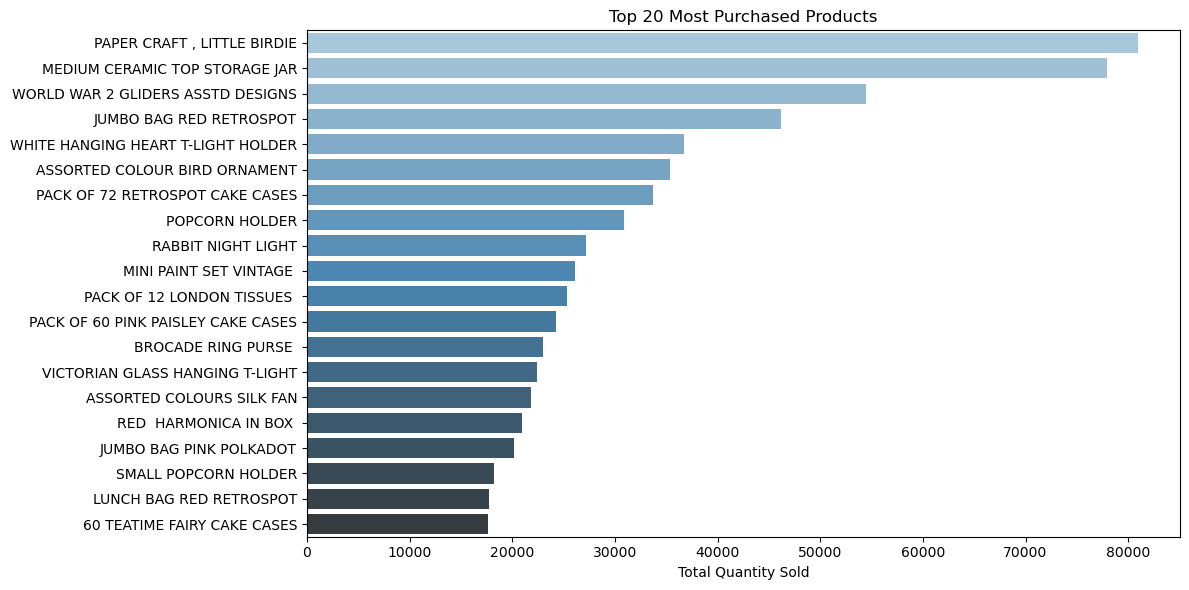

In [7]:
top_products = (df.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(20))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_d')
plt.title('Top 20 Most Purchased Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

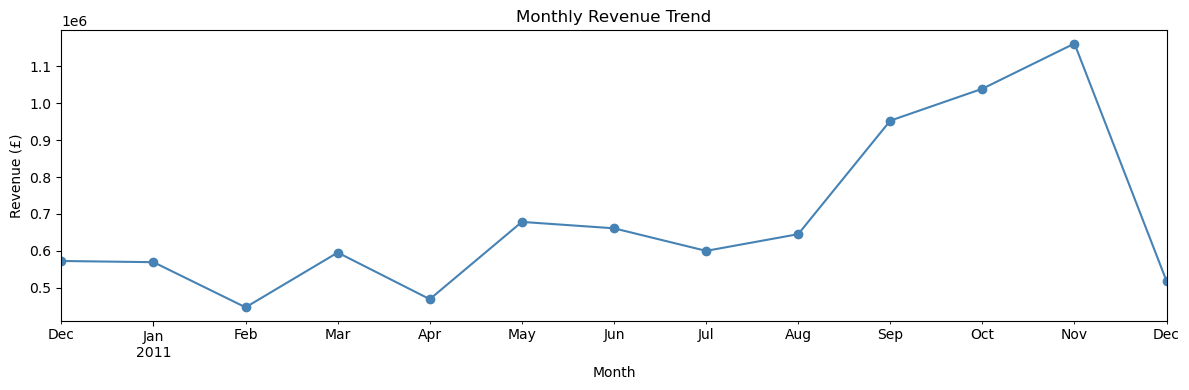

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Revenue'] = df['Quantity'] * df['Price']

monthly = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12, 4))
monthly.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

In [9]:
basket = (df[df['Country'] == 'United Kingdom']
          .groupby(['Invoice', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

basket_sets = basket.map(lambda x: True if x > 0 else False)

print(f"Basket matrix shape: {basket_sets.shape}")
print(f"Transactions: {basket_sets.shape[0]:,}")
print(f"Unique products: {basket_sets.shape[1]:,}")

Basket matrix shape: (16646, 3844)
Transactions: 16,646
Unique products: 3,844


In [10]:
import time

start = time.time()

frequent_itemsets = apriori(basket_sets,
                             min_support=0.02,
                             use_colnames=True)

rules = association_rules(frequent_itemsets,
                          metric='lift',
                          min_threshold=1.0)

end = time.time()

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(f"Association rules found: {len(rules)}")
print(f"Execution time: {round(end - start, 2)} seconds")

rules.sort_values('lift', ascending=False).head(10)

Frequent itemsets found: 235
Association rules found: 76
Execution time: 1.13 seconds


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
75,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.036766,0.023009,0.020485,0.557190,24.216650,1.0,0.019639,2.206342,0.995299,0.521407,0.546761,0.723764
70,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.023009,0.036766,0.020485,0.890339,24.216650,1.0,0.019639,8.783780,0.981284,0.521407,0.886154,0.723764
73,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",0.029617,0.028595,0.020485,0.691684,24.188581,1.0,0.019638,3.150674,0.987917,0.542994,0.682608,0.704035
72,"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.028595,0.029617,0.020485,0.716387,24.188581,1.0,0.019638,3.421500,0.986878,0.542994,0.707730,0.704035
5,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.036766,0.029617,0.024270,0.660131,22.289120,1.0,0.023181,2.855166,0.991592,0.576320,0.649758,0.739802
4,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.029617,0.036766,0.024270,0.819473,22.289120,1.0,0.023181,5.335669,0.984286,0.576320,0.812582,0.739802
71,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.024270,0.040731,0.020485,0.844059,20.723028,1.0,0.019497,6.151506,0.975418,0.460189,0.837438,0.673505
74,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.040731,0.024270,0.020485,0.502950,20.723028,1.0,0.019497,1.963041,0.992155,0.460189,0.490586,0.673505
6,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.040731,0.036766,0.028595,0.702065,19.095706,1.0,0.027098,3.233034,0.987869,0.584767,0.690693,0.739921
7,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.036766,0.040731,0.028595,0.777778,19.095706,1.0,0.027098,4.316713,0.983802,0.584767,0.768342,0.739921


In [11]:
strong_rules = rules[
    (rules['lift'] > 1) &
    (rules['confidence'] > 0.5)
].sort_values('lift', ascending=False)

print(f"Strong rules found: {len(strong_rules)}")

cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
strong_rules[cols].head(15)

Strong rules found: 30


,antecedents,consequents,support,confidence,lift
75,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.020485,0.557190,24.216650
70,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.020485,0.890339,24.216650
73,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",0.020485,0.691684,24.188581
72,"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.020485,0.716387,24.188581
5,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.024270,0.660131,22.289120
4,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.024270,0.819473,22.289120
71,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.020485,0.844059,20.723028
74,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.020485,0.502950,20.723028
6,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.028595,0.702065,19.095706
7,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.028595,0.777778,19.095706


In [13]:
strong_rules = strong_rules.copy()
strong_rules['antecedents'] = strong_rules['antecedents'].apply(
    lambda x: ', '.join(list(x))
)
strong_rules['consequents'] = strong_rules['consequents'].apply(
    lambda x: ', '.join(list(x))
)

strong_rules[['antecedents','consequents',
              'support','confidence','lift']].head(15)

,antecedents,consequents,support,confidence,lift
75,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.020485,0.557190,24.216650
70,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.020485,0.890339,24.216650
73,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",0.020485,0.691684,24.188581
72,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER,0.020485,0.716387,24.188581
5,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024270,0.660131,22.289120
4,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024270,0.819473,22.289120
71,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.020485,0.844059,20.723028
74,ROSES REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",0.020485,0.502950,20.723028
6,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.028595,0.702065,19.095706
7,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.028595,0.777778,19.095706


In [14]:
import time

results_log = []
subsets = [0.25, 0.50, 1.0]

for frac in subsets:
    sample = basket_sets.sample(frac=frac, random_state=42)
    n_transactions = len(sample)

    start = time.time()

    freq_items = apriori(sample, min_support=0.02, use_colnames=True)
    r = association_rules(freq_items, metric='lift', min_threshold=1.0)

    elapsed = round(time.time() - start, 2)

    results_log.append({
        'Subset': f"{int(frac*100)}%",
        'Transactions': n_transactions,
        'Frequent Itemsets': len(freq_items),
        'Rules Generated': len(r),
        'Execution Time (s)': elapsed
    })

    print(f"{int(frac*100)}% → {n_transactions:,} txns | "
          f"{len(r)} rules | {elapsed}s")

perf_df = pd.DataFrame(results_log)
perf_df

25% → 4,162 txns | 68 rules | 0.2s
50% → 8,323 txns | 64 rules | 0.43s
100% → 16,646 txns | 76 rules | 1.17s


,Subset,Transactions,Frequent Itemsets,Rules Generated,Execution Time (s)
0,25%,4162,220,68,0.20
1,50%,8323,221,64,0.43
2,100%,16646,235,76,1.17


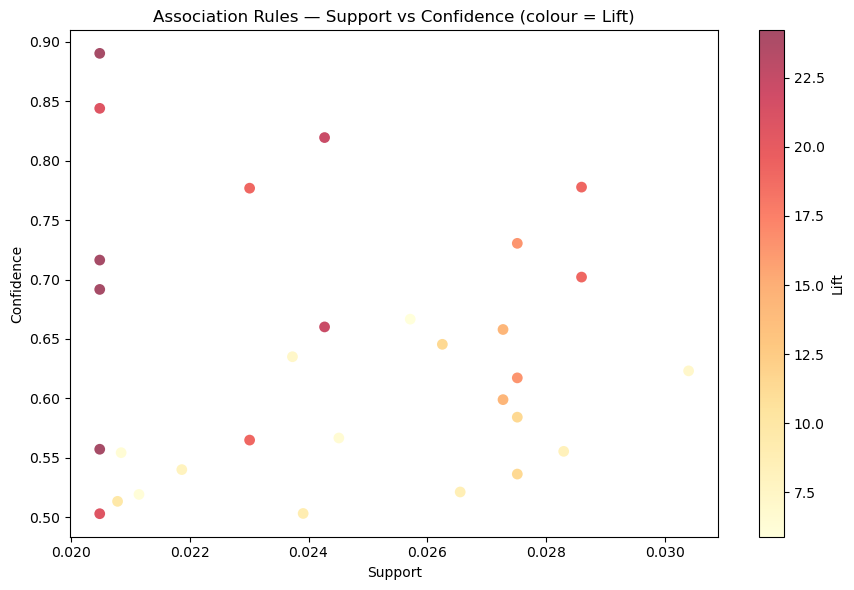

In [15]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    strong_rules['support'],
    strong_rules['confidence'],
    c=strong_rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='none',
    s=60
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules — Support vs Confidence (colour = Lift)')
plt.tight_layout()
plt.savefig('scatter_rules.png', dpi=150)
plt.show()

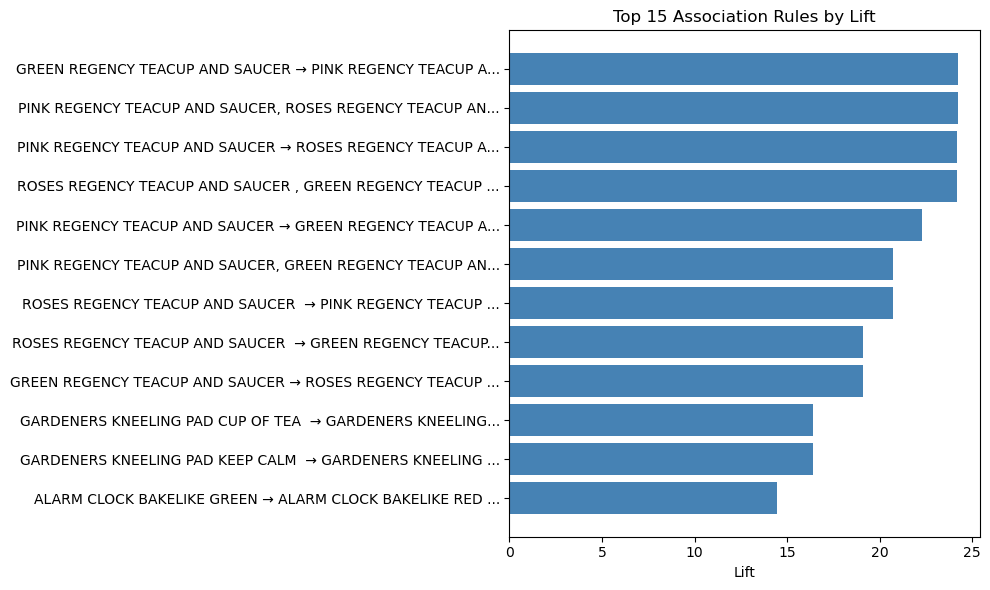

In [16]:
top15 = strong_rules.head(15).copy()
top15['rule'] = top15['antecedents'] + ' → ' + top15['consequents']
top15['rule'] = top15['rule'].str[:55] + '...'

plt.figure(figsize=(10, 6))
plt.barh(top15['rule'], top15['lift'], color='steelblue')
plt.xlabel('Lift')
plt.title('Top 15 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top15_rules_lift.png', dpi=150)
plt.show()

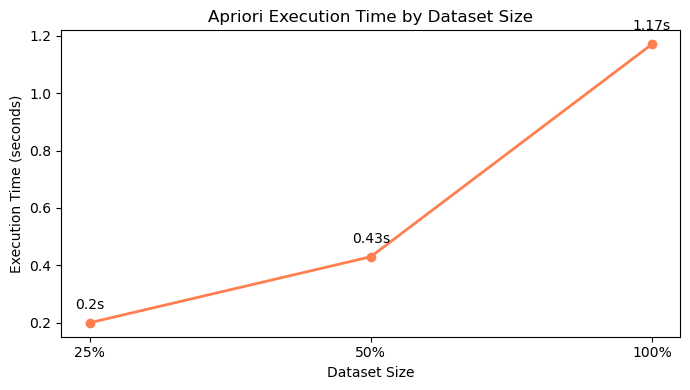

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(perf_df['Subset'], perf_df['Execution Time (s)'],
         marker='o', color='coral', linewidth=2)
for i, row in perf_df.iterrows():
    plt.annotate(f"{row['Execution Time (s)']}s",
                 (row['Subset'], row['Execution Time (s)']),
                 textcoords='offset points', xytext=(0,10),
                 ha='center', fontsize=10)
plt.xlabel('Dataset Size')
plt.ylabel('Execution Time (seconds)')
plt.title('Apriori Execution Time by Dataset Size')
plt.tight_layout()
plt.savefig('scalability_time.png', dpi=150)
plt.show()

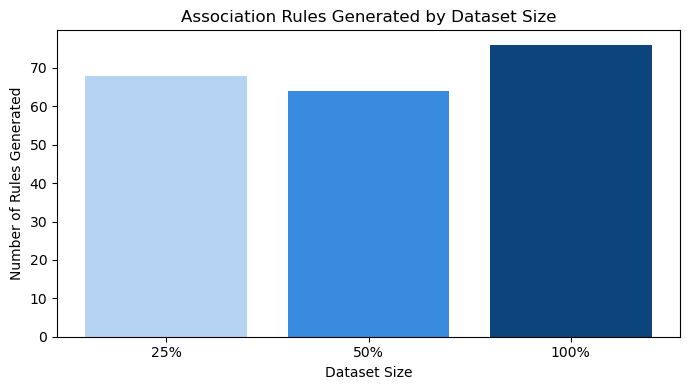

In [18]:
plt.figure(figsize=(7, 4))
plt.bar(perf_df['Subset'], perf_df['Rules Generated'],
        color=['#B5D4F4','#378ADD','#0C447C'])
plt.xlabel('Dataset Size')
plt.ylabel('Number of Rules Generated')
plt.title('Association Rules Generated by Dataset Size')
plt.tight_layout()
plt.savefig('scalability_rules.png', dpi=150)
plt.show()